# Bank Marketing Campaign Analysis

**Author:** Aamir Ali Contractor

## Business Objective

Analyze customer demographic, financial, and marketing campaign data to identify the factors associated with term-deposit subscription and provide actionable business recommendations through exploratory data analysis (EDA).

## Dataset Description

The dataset contains **45,211 customer records** collected from a Portuguese bank's direct marketing campaigns. The target variable is **`y`**, indicating whether a customer subscribed to a term deposit.

### Variables analyzed

| Category | Variables |
|---|---|
| Demographic | age, job, marital, education |
| Financial | balance, housing, loan, default |
| Campaign | contact, month, duration, campaign |
| Previous Campaign | pdays, previous, poutcome |
| Target | y |

## Business Understanding

### The EDA is being conducted for a Portugese based bank where they conducted a marketing campaign to sell their term deposit services

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import CSV file

In [2]:
df = pd.read_csv('bank-full.csv', sep = ';')

## Understand the dataset

In [3]:
df.shape

(45211, 17)

In [4]:
df.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


##### The dataset has 45211 rows and 17 columns. Each row represents a customer and their, personal and financial characteristics, previous and present campaign related infromation and whether they subscribed for the term deposit. There are numerical columns like age and balance, categorical columns like marital and occupation. Our target variable is the `y` column which indicates if the customer subscribed for the term deposit.

## Data Quality

In [8]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

##### No explicit missing values (NaN) are present in the dataset, but further investigation is required as we move ahead with the EDA. No duplicated rows were found. Certain columns have a considerable amount of unique values but given what each column represents requires further investigation to ensure data quality.

### Categorical Value Validation

In [11]:
categorical_cols = df.select_dtypes(include = 'object').columns
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [12]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default:
default
no     44396
yes      815
Name: count, dtype: int64

housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

In [13]:
for col in categorical_cols:
    print(f'\n{col}:')
    print((df[col].value_counts(normalize=True)*100).round(2))


job:
job
blue-collar      21.53
management       20.92
technician       16.80
admin.           11.44
services          9.19
retired           5.01
self-employed     3.49
entrepreneur      3.29
unemployed        2.88
housemaid         2.74
student           2.07
unknown           0.64
Name: proportion, dtype: float64

marital:
marital
married     60.19
single      28.29
divorced    11.52
Name: proportion, dtype: float64

education:
education
secondary    51.32
tertiary     29.42
primary      15.15
unknown       4.11
Name: proportion, dtype: float64

default:
default
no     98.2
yes     1.8
Name: proportion, dtype: float64

housing:
housing
yes    55.58
no     44.42
Name: proportion, dtype: float64

loan:
loan
no     83.98
yes    16.02
Name: proportion, dtype: float64

contact:
contact
cellular     64.77
unknown      28.80
telephone     6.43
Name: proportion, dtype: float64

month:
month
may    30.45
jul    15.25
aug    13.82
jun    11.81
nov     8.78
apr     6.49
feb     5.86
jan     3

#### `unknown` is present in several categorical variables. Its prevalance varies considerably between columns, with particularly high representation in `poutcome` and `contact` columns. Further investigation is required to ascertain whether `unknown` represents missing information or a meaningful category.

### Investigating `poutcome`

In [14]:
pd.crosstab(df['poutcome'], df['previous'])

previous,0,1,2,3,4,5,6,7,8,9,...,32,35,37,38,40,41,51,55,58,275
poutcome,,,,,,,,,,,,,,,,,,,,,
failure,0,1707,1362,660,405,261,146,101,54,49,...,1,1,0,2,0,0,1,1,0,0
other,0,591,390,238,165,107,64,59,46,27,...,0,0,2,0,1,1,0,0,1,1
success,0,473,352,244,144,90,67,44,29,16,...,0,0,0,0,0,0,0,0,0,0
unknown,36954,1,2,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df.groupby(['poutcome'])['previous'].describe()

,count,mean,std,min,25%,50%,75%,max
poutcome,,,,,,,,
failure,4901.0,2.896552,3.130252,1.0,1.0,2.0,3.0,55.0
other,1840.0,4.009239,7.799166,1.0,1.0,2.0,4.0,275.0
success,1511.0,3.075447,2.593854,1.0,1.0,2.0,4.0,28.0
unknown,36959.0,0.000460,0.047388,0.0,0.0,0.0,0.0,7.0


##### poutcome = unknown is strongly associated with having no previous campaign contacts. Of the 36,959 observations with an unknown previous outcome, 36,954 (99.99%) have previous = 0. Therefore, unknown appears to primarily represent customers for whom there was no previous campaign outcome to record, rather than conventional missing data. The five exceptions may warrant separate investigation later if relevant.

## Investigating `contact`

In [16]:
pd.crosstab(df['contact'], df['y'], normalize = 'index')*100

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


##### contact = unknown is associated with a substantially lower subscription rate (4.07%) compared with cellular (14.92%) and telephone (13.42%). The unknown category also represents a substantial 28.8% of observations and is strongly associated with having no previous campaign contact. However, the available analysis does not establish why the contact method is unknown.

In [17]:
df['previous_contact'] = df['previous'].gt(0)

pd.crosstab(
    df['contact'],
    df['previous_contact'],
    normalize='index'
) * 100

previous_contact,False,True
contact,,
cellular,74.198395,25.801605
telephone,78.286304,21.713696
unknown,99.462366,0.537634


In [18]:
pd.crosstab(df['contact'], 
            df['duration'].eq(0), 
            normalize = 'index'
           ) * 100


duration,False,True
contact,,
cellular,99.993171,0.006829
telephone,100.000000,0.000000
unknown,99.992320,0.007680


##### The analysis shows that contact = unknown is not associated with duration = 0. In fact, 99.99% of observations with contact = unknown have a non-zero recorded duration. Therefore, duration does not explain why the contact method is recorded as unknown, and no conclusion about the meaning of the unknown category can be drawn from this relationship.

### Numerical value validation

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Investigate campaign

In [20]:
df.loc[df['campaign']>10, 'campaign'].value_counts().sort_index()

campaign
11    201
12    155
13    133
14     93
15     84
16     79
17     69
18     51
19     44
20     43
21     35
22     23
23     22
24     20
25     22
26     13
27     10
28     16
29     16
30      8
31     12
32      9
33      6
34      5
35      4
36      4
37      2
38      3
39      1
41      2
43      3
44      1
46      1
50      2
51      1
55      1
58      1
63      1
Name: count, dtype: int64

##### campaign has a median of 2 contacts and a maximum of 63. Although higher values are considerably less frequent, the frequency generally decreases as the number of contacts increases, with no obvious indication that the extreme values are erroneous. Therefore, no further data-quality investigation is required at this stage. The distribution of campaign may be revisited during univariate analysis if it is relevant to understanding campaign effectiveness.

## Univariate Analysis

### Numerical Variables

#### Age

In [21]:
df['age'].value_counts().sort_index()

age
18     12
19     35
20     50
21     79
22    129
     ... 
90      2
92      2
93      2
94      1
95      2
Name: count, Length: 77, dtype: int64

#### Age distribution

<Axes: ylabel='Frequency'>

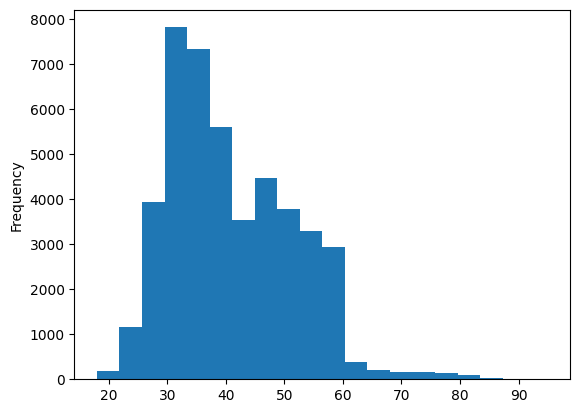

In [22]:
df['age'].plot(kind = 'hist', bins = 20)

The age distribution is moderately right-skewed, with most observations concentrated between approximately 20 and 50 years and a smaller number of observations extending into older age groups. No implausible values or obvious data-quality issues are apparent. Although a small number of customers are at the upper end of the age range, these observations are not inherently erroneous and do not warrant further investigation at this stage.

### Balance

In [23]:
df['balance'].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

In [24]:
df['balance'].value_counts().sort_index()

balance
-8019      1
-6847      1
-4057      1
-3372      1
-3313      1
          ..
 66721     1
 71188     1
 81204     2
 98417     1
 102127    1
Name: count, Length: 7168, dtype: int64

<Axes: ylabel='Frequency'>

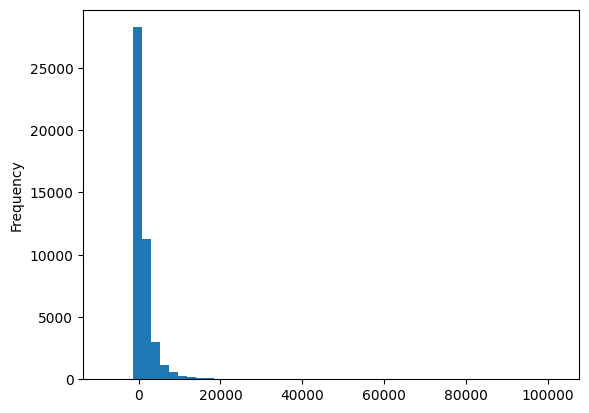

In [25]:
df['balance'].plot(kind = 'hist', bins = 50)

The balance distribution is strongly right-skewed, with most observations concentrated between zero and the low thousands. A relatively small number of customers have substantially higher balances, producing a long right tail and causing the mean (1,362) to be considerably higher than the median (448). Negative balances are present but appear to be rare. No values are inherently implausible for a banking dataset, so no data-quality correction is warranted at this stage.

#### Duration Distribution

In [26]:
df['duration'].describe()

count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

<Axes: ylabel='Frequency'>

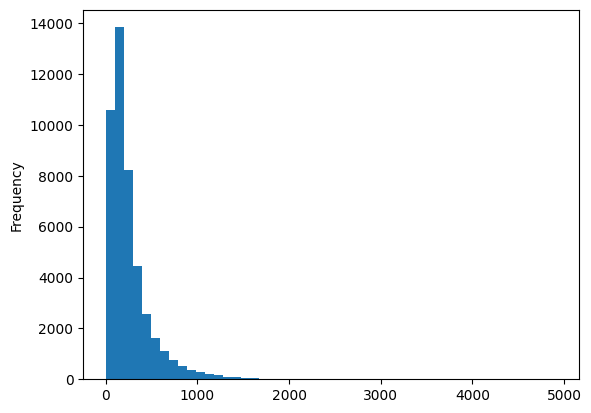

In [27]:
df['duration'].plot(kind = 'hist', bins = 50)

The duration distribution is heavily right-skewed, with most observations concentrated at relatively short contact durations and a long right tail extending to 4,918 seconds. The observations at the extreme upper end may represent statistical outliers, although this cannot be determined from the histogram alone. No values appear inherently implausible for the dataset, so no data-quality correction is warranted at this stage.

### Campaign Dstribution 

In [28]:
df['campaign'].describe()

count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

<Axes: ylabel='Frequency'>

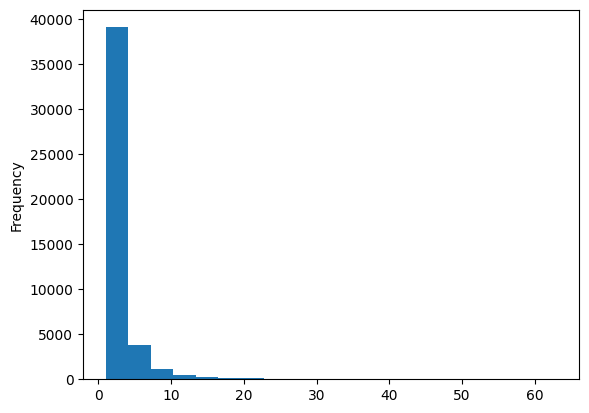

In [29]:
df['campaign'].plot(kind = 'hist', bins = 20)

The campaign distribution is heavily right-skewed, with most observations concentrated between 1 and 3 contacts and a long right tail extending into the higher contact counts. Although the maximum value of 63 is extreme relative to the typical customer, the previously observed decreasing frequency of higher campaign values provides no clear evidence that it is erroneous. Therefore, no further univariate or data-quality investigation is warranted at this stage.

### pdays

In [30]:
df['pdays'].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

In [31]:
df['pdays'].value_counts().sort_index()

pdays
-1      36954
 1         15
 2         37
 3          1
 4          2
        ...  
 838        1
 842        1
 850        1
 854        1
 871        1
Name: count, Length: 559, dtype: int64

In [32]:
df['pdays'].gt(-1).value_counts()

pdays
False    36954
True      8257
Name: count, dtype: int64

In [33]:
df.loc[df['pdays'] > -1, 'pdays'].describe().round(2)

count    8257.00
mean      224.58
std       115.34
min         1.00
25%       133.00
50%       194.00
75%       327.00
max       871.00
Name: pdays, dtype: float64

pdays contains 36,954 observations with a value of -1, representing customers who were not previously contacted. Since -1 is a meaningful sentinel value rather than an actual number of days, positive values were analysed separately. Among the 8,257 customers with a previous contact, the median time since contact was 194 days, while the maximum was 871 days. Although 871 days is an extreme observation, it is not inherently implausible and no evidence of a data-quality issue was identified.

### `previous`

In [34]:
df['previous'].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

In [35]:
df['previous'].value_counts().sort_index()

previous
0      36954
1       2772
2       2106
3       1142
4        714
5        459
6        277
7        205
8        129
9         92
10        67
11        65
12        44
13        38
14        19
15        20
16        13
17        15
18         6
19        11
20         8
21         4
22         6
23         8
24         5
25         4
26         2
27         5
28         2
29         4
30         3
32         1
35         1
37         2
38         2
40         1
41         1
51         1
55         1
58         1
275        1
Name: count, dtype: int64

The previous variable is heavily concentrated at 0, with approximately 81.7% of observations having no previous campaign contacts. The frequency decreases as the number of previous contacts increases, resulting in a long right tail. Although the highest values are rare, their decreasing frequency does not provide evidence that they are erroneous. No obvious data-quality issue is identified at this stage.

### Target Variable `y`

In [36]:
df['y'].value_counts(normalize = True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

##### The target variable is imbalanced, with 88.30% of customers not subscribing and 11.70% subscribing. This establishes a baseline subscription rate of 11.70%. Understanding which customer and campaign characteristics are associated with deviations from this baseline will be important during subsequent bivariate analysis.

## Bivariate Analysis

### Categorical variables vs target variables

### Job vs Subscription (y)

In [37]:
pd.crosstab(df['job'], df['y'], normalize = 'index')*100

y,no,yes
job,,
admin.,87.797331,12.202669
blue-collar,92.725031,7.274969
entrepreneur,91.728312,8.271688
housemaid,91.209677,8.790323
management,86.244449,13.755551
retired,77.208481,22.791519
self-employed,88.157061,11.842939
services,91.116996,8.883004
student,71.321962,28.678038


In [38]:
job_analysis = pd.crosstab(
    df['job'],
    df['y'],
    margins = True
)

job_analysis

y,no,yes,All
job,,,
admin.,4540,631,5171
blue-collar,9024,708,9732
entrepreneur,1364,123,1487
housemaid,1131,109,1240
management,8157,1301,9458
retired,1748,516,2264
self-employed,1392,187,1579
services,3785,369,4154
student,669,269,938


In [39]:
job_analysis['yes_percentage'] = (
    job_analysis['yes']/job_analysis['All']*100
)
job_analysis.sort_values('yes_percentage', ascending = False)

y,no,yes,All,yes_percentage
job,,,,
student,669,269,938,28.678038
retired,1748,516,2264,22.791519
unemployed,1101,202,1303,15.502686
management,8157,1301,9458,13.755551
admin.,4540,631,5171,12.202669
self-employed,1392,187,1579,11.842939
unknown,254,34,288,11.805556
All,39922,5289,45211,11.698480
technician,6757,840,7597,11.056996


### Job vs Subscription Rate

In [40]:
job_rate = (
    df.groupby('job')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=False)
)

job_rate

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64

<Axes: xlabel='job'>

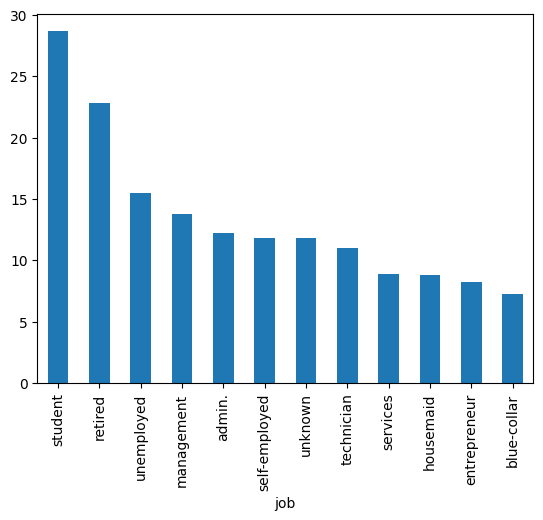

In [41]:
job_rate.plot(kind='bar')

##### Subscription rates vary considerably across job categories. Students (28.68%), retired customers (22.79%), and unemployed customers (15.50%) have subscription rates above the overall baseline of 11.70%, while blue-collar (7.27%), entrepreneur (8.27%), services (8.88%), and housemaid (8.79%) categories fall below the baseline. There is no clear gradual pattern across job categories.

### Education vs Subscription

In [42]:
pd.crosstab(df['education'], df['y'], normalize = 'index')*100

y,no,yes
education,,
primary,91.373522,8.626478
secondary,89.440565,10.559435
tertiary,84.993610,15.006390
unknown,86.429725,13.570275


#### Education distribution among students

In [43]:
pd.crosstab(
    df[df['job'] == 'student']['education'],
    df[df['job'] == 'student']['y'],
    normalize = 'index'
)*100

y,no,yes
education,,
primary,63.636364,36.363636
secondary,70.275591,29.724409
tertiary,73.542601,26.457399
unknown,73.619632,26.380368


### Conclusion

##### Subscription rates vary across job categories, with students and retired customers showing substantially higher rates than the overall baseline, while blue-collar, entrepreneur, services, and housemaid customers show lower rates. An investigation into whether education explained the high student subscription rate did not support the hypothesis, as subscription rates among students decreased with higher education levels. No further investigation of the job–subscription relationship is required at this stage.

### Loan vs Subscription

In [44]:
pd.crosstab(
    df['loan'],
    df['y'],
    normalize = 'index'
).round(2)*100

y,no,yes
loan,,
no,87.0,13.0
yes,93.0,7.0


#### Personal Loan vs Hosing Loan

In [45]:
pd.crosstab(
    df['loan'],
    df['housing'],
    normalize = 'index'
).round(2) *100

housing,no,yes
loan,,
no,45.0,55.0
yes,40.0,60.0


Customers with a personal loan are somewhat more likely to also have a housing loan: 60% of customers with a personal loan have a housing loan, compared with 55% of customers without a personal loan. The difference is relatively modest, so this does not by itself explain the lower subscription rate among customers with personal loans.

### Conclusion 

Customers with a personal loan have a lower subscription rate (7.0%) than the overall baseline (11.70%), while customers without a personal loan have a slightly higher rate (13.0%). An investigation of the relationship between personal and housing loans found only a modest difference in housing-loan prevalence (60% vs 55%), which does not sufficiently explain the observed subscription difference. No further investigation of this relationship is warranted at this stage.

### Hosing Loan vs Subscription

In [46]:
pd.crosstab(
    df['housing'],
    df['y'],
    normalize = 'index'
).round(3)*100

y,no,yes
housing,,
no,83.3,16.7
yes,92.3,7.7


### Housing and Personal Loan combined

In [47]:
pd.crosstab(
    [df['housing'], df['loan']],
    df['y'],
    normalize = 'index'
)*100

y                    no        yes
housing loan                      
no      no    81.777494  18.222506
        yes   92.387904   7.612096
yes     no    91.956846   8.043154
        yes   93.931761   6.068239

Housing and personal loan status are both associated with term-deposit subscription. Customers with neither type of loan have the highest observed subscription rate (18.22%), while customers with both have the lowest (6.07%). Customers with only a housing loan (8.04%) or only a personal loan (7.61%) also show substantially lower subscription rates than the overall baseline of 11.70%. This suggests that existing loan status may be an important factor associated with subscription behaviour, although the analysis does not establish causality.

### Marital Status vs Subscription

In [48]:
pd.crosstab(
    df['marital'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
marital,,
divorced,88.054542,11.945458
married,89.876534,10.123466
single,85.050821,14.949179


Subscription rates show some variation across marital-status groups, with single customers having the highest rate (14.95%) and married customers the lowest (10.12%). However, the differences from the overall subscription rate of 11.70% are relatively modest, so the marital-status relationship does not warrant further investigation at this stage.

### Credit Default Status vs Subscription

In [49]:
pd.crosstab(
    df['default'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
default,,
no,88.203892,11.796108
yes,93.619632,6.380368


In [50]:
default_analysis = pd.crosstab(
    df['default'],
    df['y'],
    margins = True
)

default_analysis

y,no,yes,All
default,,,
no,39159,5237,44396
yes,763,52,815
All,39922,5289,45211


Customers with credit in default have a lower observed subscription rate (6.38%) than the overall baseline (11.70%). However, the default = yes category represents only 815 observations (1.8% of the dataset), making it substantially smaller than the default = no group. The difference is potentially interesting, but the relatively small subgroup warrants caution when interpreting the result.

### Contact Method vs Subscription

In [51]:
pd.crosstab(
    df['contact'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


In [52]:
pd.crosstab(
    df['contact'],
    df['y'],
    margins = True
)

y,no,yes,All
contact,,,
cellular,24916,4369,29285
telephone,2516,390,2906
unknown,12490,530,13020
All,39922,5289,45211


Customers with an unknown contact method have a substantially lower subscription rate (4.07%) than the overall baseline (11.70%). The unknown category represents 13,020 observations and is strongly associated with zero recorded contact duration, suggesting that these observations largely represent cases where no contact conversation was recorded.

### Campaign Month vs SUbscription

In [54]:
pd.crosstab(
    df['month'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
month,,
apr,80.320600,19.679400
aug,88.986714,11.013286
dec,53.271028,46.728972
feb,83.352208,16.647792
jan,89.878831,10.121169
jul,90.906454,9.093546
jun,89.777195,10.222805
mar,48.008386,51.991614
may,93.280546,6.719454


In [55]:
pd.crosstab(
    df['month'],
    df['y'],
    margins = True
)

y,no,yes,All
month,,,
apr,2355,577,2932
aug,5559,688,6247
dec,114,100,214
feb,2208,441,2649
jan,1261,142,1403
jul,6268,627,6895
jun,4795,546,5341
mar,229,248,477
may,12841,925,13766


Subscription rates vary substantially across campaign months. March, December, September and October show exceptionally high subscription rates (43.77–51.99%), although these months contain relatively few observations. In contrast, May contains the largest number of observations (13,766) and has a relatively low subscription rate of 6.72%, approximately 5 percentage points below the overall baseline of 11.70%. The substantial variation across months warrants further investigation.

Could differences in the job composition of customers across campaign months help explain the large variation in monthly subscription rates?

Were the types of customers being contacted substantially different in different months?

In [56]:
pd.crosstab(
    df['month'],
    df['job'],
    normalize='index'
) * 100

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
month,,,,,,,,,,,,
apr,13.778990,25.682128,2.387449,1.739427,18.894952,4.945430,2.933151,9.549795,3.035471,14.699864,2.114598,0.238745
aug,5.778774,9.748679,1.312630,4.178005,31.663198,6.259004,3.409637,4.274052,1.760845,29.117977,1.488715,1.008484
dec,10.747664,5.607477,1.401869,2.803738,23.831776,19.158879,2.803738,7.009346,7.943925,14.485981,3.738318,0.467290
feb,11.853530,15.213288,3.284258,1.925255,20.951302,6.342016,3.963760,7.927520,3.510759,16.043790,8.493771,0.490751
jan,12.687099,13.186030,2.708482,2.280827,20.669993,6.343550,3.777619,9.622238,2.779758,17.747684,7.127584,1.069138
jul,12.632342,20.246555,4.379985,4.089920,19.593909,4.916606,3.582306,11.254532,1.044235,15.242930,2.567078,0.449601
jun,11.046620,23.965550,4.044186,5.092679,17.318854,5.673095,3.988017,9.679835,1.591462,12.937652,2.976971,1.685078
mar,15.513627,5.031447,0.419287,2.725367,30.188679,13.836478,3.354298,4.192872,8.176101,11.949686,3.983229,0.628931
may,12.719744,31.802993,3.021938,1.096905,15.748947,2.571553,2.658724,11.550196,1.837861,14.819120,1.946826,0.225193


Job composition varies substantially across campaign months. For example, blue-collar customers represented 5.03% of observations in March compared with 31.80% in May. Since job category is itself associated with subscription rates, differences in customer composition may contribute to the observed variation in monthly subscription rates. However, this relationship has not been formally investigated further.

### Previous Campaign Outcome vs Subscription

Does the outcome of a customer's previous campaign relate to whether they subscribe during the current campaign?

In [57]:
pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


In [58]:
pd.crosstab(
    df['poutcome'],
    df['y'],
    margins = True
)

y,no,yes,All
poutcome,,,
failure,4283,618,4901
other,1533,307,1840
success,533,978,1511
unknown,33573,3386,36959
All,39922,5289,45211


Previous campaign outcome shows a strong association with current term-deposit subscription. Customers whose previous campaign resulted in a successful outcome have a subscription rate of 64.73%, substantially higher than the overall rate of 11.70%. Although the success category contains fewer observations (1,511) than unknown, it is sufficiently large to make the observed difference noteworthy. This relationship warrants consideration as an important predictor of current campaign outcomes, although the analysis does not establish causality.

### Numerical Variables vs Target variable

### `age`
##### Do subscription rates meaninfully differ among age groups?

In [59]:
age_bins = [17, 25, 35, 45, 55, 65, 100]

age_labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '66+'
]

df['age_groups'] = pd.cut(
    df['age'],
    bins = age_bins,
    labels = age_labels
)

In [60]:
df['age_groups'].value_counts().sort_index()

age_groups
18-25     1336
26-35    15571
36-45    13856
46-55     9548
56-65     4149
66+        751
Name: count, dtype: int64

In [61]:
pd.crosstab(df['age_groups'],
            df['y'],
            normalize = 'index'
           )*100

y,no,yes
age_groups,,
18-25,76.047904,23.952096
26-35,87.996917,12.003083
36-45,90.610566,9.389434
46-55,90.647256,9.352744
56-65,85.876115,14.123885
66+,57.390146,42.609854


Are the unusually high subscription rates among 18–25 and 66+ being driven by some particular customer characteristic?

Could the unusual age-group subscription rates be partly related to the types of jobs represented within those age groups?

In [62]:
pd.crosstab(
    df.loc[df['age_groups'].isin(['18-25','66+']), 'age_groups'],
    df.loc[df['age_groups'].isin(['18-25','66+']), 'job'],
    normalize = 'index'
)*100

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
age_groups,,,,,,,,,,,,
18-25,11.826347,19.835329,1.047904,0.523952,8.158683,0.149701,1.871257,12.050898,30.688623,11.751497,1.946108,0.149701
66+,1.198402,0.798935,0.532623,3.728362,4.793609,84.553928,1.065246,0.133156,0.000000,1.597870,0.133156,1.464714


The 18–25 and 66+ age groups show substantially higher subscription rates than the overall baseline. Investigation of job composition suggests that these age groups have very different occupational profiles: students account for 30.69% of the 18–25 group, while retired customers account for 84.55% of the 66+ group. Since students and retired customers were previously found to have relatively high subscription rates, job composition may partly contribute to the higher subscription rates observed in these age groups. This analysis does not establish causality or determine the extent to which job composition explains the age-group differences.

### `balance` vs `y`

### Are customers with different account balances associated with different subscription rates?

In [63]:
df['balance_group'] = pd.qcut(
    df['balance'],
    q=4,
    labels = ['Q1 - Lowest', 'Q2', 'Q3', 'Q4 - Highest']
)

df['balance_group'].value_counts().sort_index()

balance_group
Q1 - Lowest     11317
Q2              11291
Q3              11306
Q4 - Highest    11297
Name: count, dtype: int64

In [64]:
df.groupby('balance_group', observed = True)['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
balance_group,,,,,,,,
Q1 - Lowest,11317.0,-95.019086,265.238261,-8019.0,-92.0,0.0,12.0,72.0
Q2,11291.0,241.565140,107.372364,73.0,147.0,233.0,330.0,448.0
Q3,11306.0,839.354414,278.976583,449.0,595.0,786.5,1060.0,1428.0
Q4 - Highest,11297.0,4465.589094,4863.708221,1429.0,2010.0,2987.0,5024.0,102127.0


In [65]:
pd.crosstab(
    df['balance_group'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
balance_group,,
Q1 - Lowest,92.763100,7.236900
Q2,89.106368,10.893632
Q3,87.484521,12.515479
Q4 - Highest,83.845269,16.154731


There is an observed association between balance quartile and subscription rate, with subscription rates increasing across the balance quartiles.

Is this relationship simply a result of the extreme values within Q4, given how heavily right-skewed balance is?

In [66]:
df[df['balance']>10000]['y'].value_counts(normalize = 'index')*100

y
no     83.71532
yes    16.28468
Name: proportion, dtype: float64

In [67]:
df[df['balance'] > 10000].shape[0]

829

Subscription rates increased progressively across balance quartiles, from 7.24% in Q1 to 16.15% in Q4. This indicates an observed positive association between account balance and term-deposit subscription. All quartiles contained approximately equal numbers of observations, so the comparison is not being driven by a very small subgroup.

An exploratory check of customers with balances above ₹10,000 produced a subscription rate of 16.28% across 829 observations. However, ₹10,000 was not derived from a business-defined threshold or a data-driven boundary, so this result is not treated as a primary finding.

### `duration` vs `y`
#### Is the length of a marketing call associated with whether a customer subscribes to the term deposit?

In [68]:
df['duration_group'] = pd.qcut(
    df['duration'],
    q = 4,
    labels = ['Q1- Shortest', 'Q2', 'Q3', 'Q4 - Longest']
)

In [70]:
df['duration_group'].value_counts().sort_index()

duration_group
Q1- Shortest    11375
Q2              11285
Q3              11290
Q4 - Longest    11261
Name: count, dtype: int64

In [73]:
df.groupby('duration_group', observed = True)['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
duration_group,,,,,,,,
Q1- Shortest,11375.0,62.628044,27.670362,0.0,42.0,67.0,86.0,103.0
Q2,11285.0,140.273372,22.008481,104.0,121.0,139.0,159.0,180.0
Q3,11290.0,240.299646,39.112799,181.0,206.0,236.0,271.0,319.0
Q4 - Longest,11261.0,591.727999,315.186227,320.0,385.0,487.0,686.0,4918.0


In [74]:
pd.crosstab(
    df['duration_group'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
duration_group,,
Q1- Shortest,98.883516,1.116484
Q2,94.842712,5.157288
Q3,88.795394,11.204606
Q4 - Longest,70.562117,29.437883


In [88]:
q4 = df[df['duration_group'] == 'Q4 - Longest'].copy()

q4['duration_q4'] = pd.qcut(
    q4['duration'],
    q=4,
    labels=['Q4A', 'Q4B', 'Q4C', 'Q4D']
)

q4.groupby('duration_q4', observed = True)['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
duration_q4,,,,,,,,
Q4A,2847.0,350.238497,18.909975,320.0,334.00,349.0,366.0,385.0
Q4B,2799.0,431.347267,29.574324,386.0,405.00,428.0,456.0,487.0
Q4C,2809.0,574.468138,56.424512,488.0,525.00,568.0,622.0,686.0
Q4D,2806.0,1014.004989,361.699575,687.0,772.25,903.0,1135.0,4918.0


In [79]:
pd.crosstab(
    q4['duration_q4'],
    q4['y'],
    normalize = 'index'
)*100

y,no,yes
duration_q4,,
Q4A,85.072006,14.927994
Q4B,79.992855,20.007145
Q4C,69.455322,30.544678
Q4D,47.540984,52.459016


The duration of the marketing call shows a strong positive association with term-deposit subscription. Subscription rates increase consistently across the duration quartiles, from 1.12% among the shortest calls (0–103 seconds) to 29.44% among the longest calls (320–4918 seconds), indicating that customers engaged in longer conversations were substantially more likely to subscribe.

Further investigation of the fourth duration quartile showed that this relationship persists within the group itself. Subscription rates increased progressively from 14.93% in Q4A (320–385 seconds) to 52.46% in Q4D (687–4918 seconds), demonstrating that progressively longer call durations are associated with progressively higher subscription rates rather than the result of a single extreme subgroup.

duration should be interpreted carefully. Although it is one of the strongest variables associated with subscription, it is recorded after the phone call has taken place. Therefore, it is appropriate for evaluating campaign performance and understanding customer behaviour, but it should not be used as a predictor in a model designed to identify customers before they are contacted, as this would introduce data leakage.

### `pdays`

### Is the number of days since the previous campaign associated with whether a customer subscribes?

In [89]:
df['pdays'].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

In [90]:
df['previous_contact_status'] = np.where(
    df['pdays'] == -1,
    'Not contacted',
    'Previously contacted'
)

In [91]:
pd.crosstab(
    df['previous_contact_status'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
previous_contact_status,,
Not contacted,90.842669,9.157331
Previously contacted,76.928667,23.071333


The pdays variable shows a clear association with term-deposit subscription when interpreted according to its business meaning. Customers who were previously contacted have a subscription rate of 23.07%, which is 11.37 percentage points above the overall dataset baseline of 11.70%. In contrast, customers who were not previously contacted have a subscription rate of 9.16%, slightly below the baseline.

### `previous` 

### Does the count of previous contacts have an associated with subscription?

In [92]:
df['previous_group'] = pd.qcut(
    df['previous'],
    q=4,
    duplicates = 'drop'
)

Why? Because 81.7% of customers have previous = 0. When many values are identical, qcut() may be unable to create four unique quartiles. This parameter tells Pandas to drop duplicate cut points rather than raise an error.

In [95]:
df.groupby('previous_group', observed=True)['previous'].describe()

,count,mean,std,min,25%,50%,75%,max
previous_group,,,,,,,,
"(-0.001, 275.0]",45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


The first three quartile boundaries all fall on 0, so they become duplicate cut points. Because we used: duplicates='drop'. Pandas removes those duplicate boundaries and is left with one interval:

(-0.001, 275]. That odd-looking -0.001 is not a real value. It's just Pandas slightly extending the lower bound so that the interval includes 0

In [96]:
df.drop(columns = 'previous_group', inplace = True)

In [97]:
df['previous'].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

In [99]:
df['previous_group'] = pd.cut(
    df['previous'],
    bins = [-1, 0, 1, 3, 275],
    labels = ['0', '1', '2-3', '4+']
)

In [100]:
df.groupby('previous_group', observed = True)['previous'].describe()

,count,mean,std,min,25%,50%,75%,max
previous_group,,,,,,,,
0,36954.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,2772.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
2-3,3248.0,2.351601,0.477544,2.0,2.0,2.0,3.0,3.0
4+,2237.0,7.075101,7.376029,4.0,4.0,5.0,8.0,275.0


In [101]:
pd.crosstab(
    df['previous_group'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
previous_group,,
0,90.842669,9.157331
1,78.968254,21.031746
2-3,76.908867,23.091133
4+,74.430040,25.569960


The number of previous campaign contacts shows a positive association with term-deposit subscription. Customers with no previous contacts have a subscription rate of 9.16%, while customers contacted once, 2–3 times, and 4+ times have progressively higher subscription rates of 21.03%, 23.09%, and 25.57%, respectively. This suggests that prior engagement with customers is associated with a higher likelihood of subscribing, with a modest increase as the number of previous contacts rises.

Connection to pdays

This finding is consistent with our earlier analysis of pdays. There, we found that customers who had been previously contacted were substantially more likely to subscribe than those who had never been contacted. The previous analysis extends that insight by showing that, among previously contacted customers, repeated engagement is also associated with gradually higher subscription rates.

### `campaign`

### Is the number of contacts made during the current campaign associated with subscription?

In [103]:
df['campaign_group']  = pd.cut(
    df['campaign'],
    bins = [0, 1, 2, 3, 63],
    labels = ['1', '2', '3','4']
)

In [104]:
df['campaign_group'].value_counts().sort_index()

campaign_group
1    17544
2    12505
3     5521
4     9641
Name: count, dtype: int64

In [105]:
pd.crosstab(
    df['campaign_group'],
    df['y'],
    normalize = 'index'
)*100

y,no,yes
campaign_group,,
1,85.402417,14.597583
2,88.796481,11.203519
3,88.806376,11.193624
4,92.645991,7.354009


The number of contacts made during the current campaign shows a negative association with term-deposit subscription. Customers contacted once have the highest subscription rate (14.60%), approximately 2.90 percentage points above the dataset baseline of 11.70%. Subscription rates decline with additional contacts, reaching 7.35% among customers contacted four or more times.

This suggests that repeated contact within the same campaign is associated with lower conversion rates, whereas successful subscriptions are more commonly observed after the initial contact.

Connection to previous

This finding complements the earlier previous analysis rather than contradicting it. While previous campaign engagement is associated with higher subscription rates, repeated contacts within the current campaign are associated with lower subscription rates. The two variables measure different aspects of customer interaction and should therefore be interpreted independently.

## Multivariate Analysis

Does housing loan still matter across different balance levels?

In [110]:
df.groupby('balance_group', observed = True)['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
balance_group,,,,,,,,
Q1 - Lowest,11317.0,-95.019086,265.238261,-8019.0,-92.0,0.0,12.0,72.0
Q2,11291.0,241.565140,107.372364,73.0,147.0,233.0,330.0,448.0
Q3,11306.0,839.354414,278.976583,449.0,595.0,786.5,1060.0,1428.0
Q4 - Highest,11297.0,4465.589094,4863.708221,1429.0,2010.0,2987.0,5024.0,102127.0


In [109]:
pd.crosstab(
    [df['housing'], df['balance_group']],
    df['y'],
    normalize = 'index'
)*100

y                             no        yes
housing balance_group                      
no      Q1 - Lowest    91.470772   8.529228
        Q2             83.564523  16.435477
        Q3             81.505421  18.494579
        Q4 - Highest   77.709790  22.290210
yes     Q1 - Lowest    93.717358   6.282642
        Q2             93.142507   6.857493
        Q3             91.889401   8.110599
        Q4 - Highest   90.138067   9.861933

Both account balance and housing loan status are associated with term-deposit subscription.

Customers without a housing loan consistently have higher subscription rates than those with a housing loan across every balance quartile. At the same time, subscription rates increase as account balance increases, regardless of housing loan status.

This suggests that the positive association between higher balances and subscription is not explained solely by housing loan status, and the housing loan effect remains consistent across different balance levels.

## Age + Job Vs Subscription

#### Are the higher subscription rates among the 18–25 and 66+ age groups partly explained by their occupations?

In [113]:
pd.crosstab(
    df.loc[df['age_groups'].isin(['18-25', '66+']), 'age_groups'],
    df.loc[df['age_groups'].isin(['18-25', '66+']), 'job'],
    normalize='index'
) * 100

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
age_groups,,,,,,,,,,,,
18-25,11.826347,19.835329,1.047904,0.523952,8.158683,0.149701,1.871257,12.050898,30.688623,11.751497,1.946108,0.149701
66+,1.198402,0.798935,0.532623,3.728362,4.793609,84.553928,1.065246,0.133156,0.000000,1.597870,0.133156,1.464714


The unusually high subscription rates in the 18–25 and 66+ age groups appear to be partly associated with their job composition. The 18–25 group contains a high proportion of students, while the 66+ group is predominantly retired. Since both occupations were previously associated with higher subscription rates, occupation may partly explain the higher subscription rates observed in these age groups.

## Poutcome + Previous Vs Subscription

In [114]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,previous,poutcome,y,previous_contact,age_groups,balance_group,duration_group,previous_contact_status,previous_group,campaign_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,0,unknown,no,False,56-65,Q4 - Highest,Q3,Not contacted,0,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,0,unknown,no,False,36-45,Q1 - Lowest,Q2,Not contacted,0,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,0,unknown,no,False,26-35,Q1 - Lowest,Q1- Shortest,Not contacted,0,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,0,unknown,no,False,46-55,Q4 - Highest,Q1- Shortest,Not contacted,0,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,0,unknown,no,False,26-35,Q1 - Lowest,Q3,Not contacted,0,1


In [115]:
pd.crosstab(
    [df['previous_group'], df['poutcome']],
    df['y'],
    normalize = 'index'
)*100

y                                no         yes
previous_group poutcome                        
0              unknown    90.842669    9.157331
1              failure    88.869361   11.130639
               other      84.602369   15.397631
               success    36.363636   63.636364
               unknown     0.000000  100.000000
2-3            failure    86.894164   13.105836
               other      83.121019   16.878981
               success    36.577181   63.422819
               unknown    50.000000   50.000000
4+             failure    86.092150   13.907850
               other      82.286634   17.713366
               success    32.352941   67.647059
               unknown   100.000000    0.000000

The outcome of the previous campaign appears to matter more than the number of previous contacts. Across customers with 1, 2–3, and 4+ previous contacts, those whose previous campaign was successful consistently have subscription rates of about 63–68%, while those with a failed previous campaign remain around 11–14%.

This suggests that the quality of the previous customer interaction is more strongly associated with subscription than simply contacting the customer more frequently.

## Objective

Analyze customer demographic, financial, and campaign data to identify the factors associated with term-deposit subscription and generate insights that can improve the effectiveness of future marketing campaigns.

Overall subscription rate was 11.7%, indicating that most customers did not subscribe.

Customers with a successful previous campaign had the highest subscription rates (~63–68%), making previous campaign outcome the strongest predictor of customer response.

Longer call durations were associated with substantially higher subscription rates, reaching 52.5% among the longest-call subgroup.

Customers without housing loans consistently subscribed more than those with housing loans across every balance quartile.

Subscription rates increased with higher account balances, from 7.2% in the lowest quartile to 16.2% in the highest.

Students and retired customers showed higher subscription rates, partly explaining the strong performance of the 18–25 and 66+ age groups.

## Business Recommendations

Prioritize customers with a successful history in previous campaigns for future outreach.

Segment customers by account balance and housing loan status to identify higher-probability prospects.

Focus on improving the quality of customer conversations, as longer and more engaging calls are associated with higher conversions.

Reduce excessive repeat calls within the same campaign, since customers contacted four or more times showed lower conversion rates than those contacted once.

## Limitations

The analysis identifies associations, not causation.

duration should not be used as a pre-campaign predictive feature because it is recorded after the phone call.

Some categories (such as certain unknown combinations) contain very small sample sizes and were not used for substantive conclusions.

# Executive Summary

## Key Findings

- The overall term-deposit subscription rate was **11.7%**.
- Previous campaign **success** showed the strongest association with subscription (**~64–68%**).
- Longer call durations were associated with progressively higher subscription rates, reaching **52.5%** in the longest duration subgroup.
- Customers without housing loans consistently subscribed more than those with housing loans across every balance quartile.
- Higher account balances were associated with higher subscription rates.
- Students and retired customers exhibited higher subscription rates than most other occupational groups.

## Business Recommendations

1. Prioritize customers with successful previous campaign outcomes for future outreach.
2. Segment customers using account balance and housing loan status to improve targeting.
3. Focus on improving the quality of customer conversations rather than increasing repeated calls.
4. Use previous engagement history as a valuable input when planning future campaigns.

## Project Limitations

- This analysis identifies **associations, not causation**.
- `duration` should not be used in pre-call predictive models because it is only known after the call.
- Small sample-size categories were excluded from substantive business conclusions.
